In [28]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from importlib.resources import files

from shrecc.database import load_time_series_data, prepare_consumption_data
from shrecc.tyndp import consumption_mix_from_tyndp_scenario

%load_ext jupyter_black

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black


In [2]:
Z_cons_2025 = load_time_series_data("../data", 2025)
Z_cons_to_multiply = prepare_consumption_data(Z_cons_2025)

In [3]:
# Plot the Luxembourg consumption mix

Z_cons_2025_LU = Z_cons_to_multiply.xs("LU", level="country", axis=1)
index_order = Z_cons_2025_LU.sum(axis=1).sort_values(ascending=False).index
Z_cons_2025_LU = Z_cons_2025_LU.reindex(index=index_order)


index_order_reg = index_order.get_level_values("geography_mix").unique()
index_order_tech = index_order.get_level_values("source").unique()


# ...by country
Z_cons_2025_LU_reg = (
    Z_cons_2025_LU.groupby("geography_mix", axis=0).sum().reindex(index=index_order_reg)
)

# ...by technology
Z_cons_2025_LU_tech = (
    Z_cons_2025_LU.groupby("source", axis=0).sum().reindex(index=index_order_tech)
)

C:\Users\Gibon\AppData\Local\Temp\ipykernel_30612\3192565296.py:14: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  Z_cons_2025_LU.groupby("geography_mix", axis=0).sum().reindex(index=index_order_reg)
C:\Users\Gibon\AppData\Local\Temp\ipykernel_30612\3192565296.py:19: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  Z_cons_2025_LU.groupby("source", axis=0).sum().reindex(index=index_order_tech)


In [4]:
# Pick typical weeks

In [5]:
max_lignite = (
    Z_cons_2025_LU_tech.rolling(window=24 * 7, min_periods=1, axis=1)
    .sum()
    .loc["Brown coal"]
    .argmax()
)
max_solar = (
    Z_cons_2025_LU_tech.rolling(window=24 * 7, min_periods=1, axis=1)
    .sum()
    .loc["Solar"]
    .argmax()
)

C:\Users\Gibon\AppData\Local\Temp\ipykernel_30612\2255625235.py:2: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  Z_cons_2025_LU_tech.rolling(window=24 * 7, min_periods=1, axis=1)
C:\Users\Gibon\AppData\Local\Temp\ipykernel_30612\2255625235.py:8: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  Z_cons_2025_LU_tech.rolling(window=24 * 7, min_periods=1, axis=1)


In [6]:
def apply_top_n_cutoff(Z, top_n, rest_label="REST"):
    """Keep rows with the largest row totals and aggregate all others."""
    row_totals = Z.sum(axis=1)
    top_rows = row_totals.nlargest(top_n).index

    top = Z.loc[top_rows].copy()
    rest = Z.drop(index=top_rows).sum(axis=0)

    if not rest.empty and len(Z) > top_n:
        top.loc[rest_label, :] = rest

    return top

In [ ]:
# All disaggregation

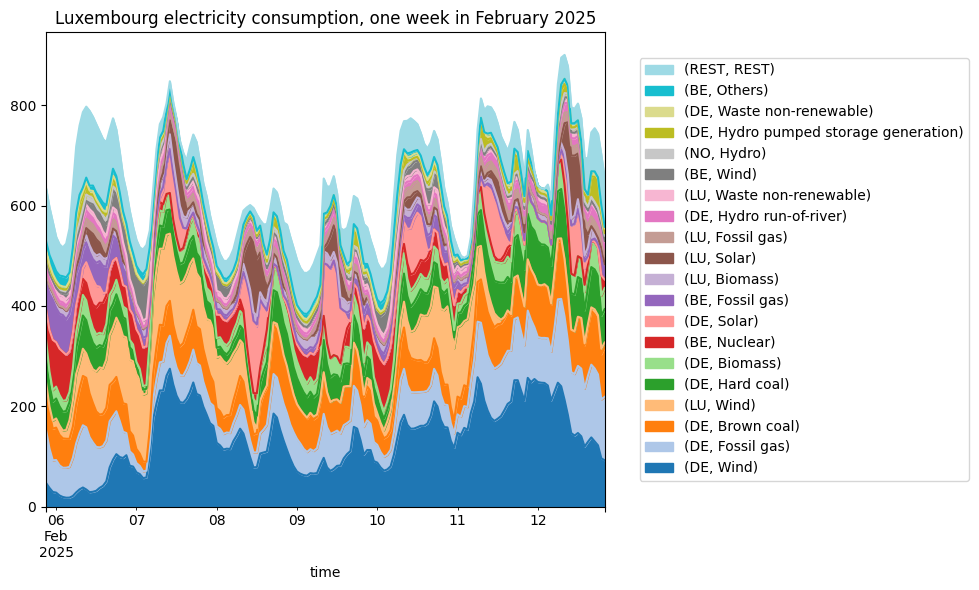

In [30]:
title = "Luxembourg electricity consumption, one week in February 2025"

Z_to_plot = apply_top_n_cutoff(
    Z=Z_cons_2025_LU.iloc[:, max_lignite : max_lignite + 24 * 7],
    top_n=19,
    rest_label=("REST", "REST"),
    # ).droplevel("source", axis=0)
).droplevel("source", axis=1)

ax = Z_to_plot.clip(0).T.plot.area(stacked=True, figsize=(10, 6), colormap="tab20")
h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1], bbox_to_anchor=(1.05, 0.5), loc="center left")
ax.set_title(title)

plt.tight_layout()

plt.savefig(f"../figures/{title}.png", dpi=300)

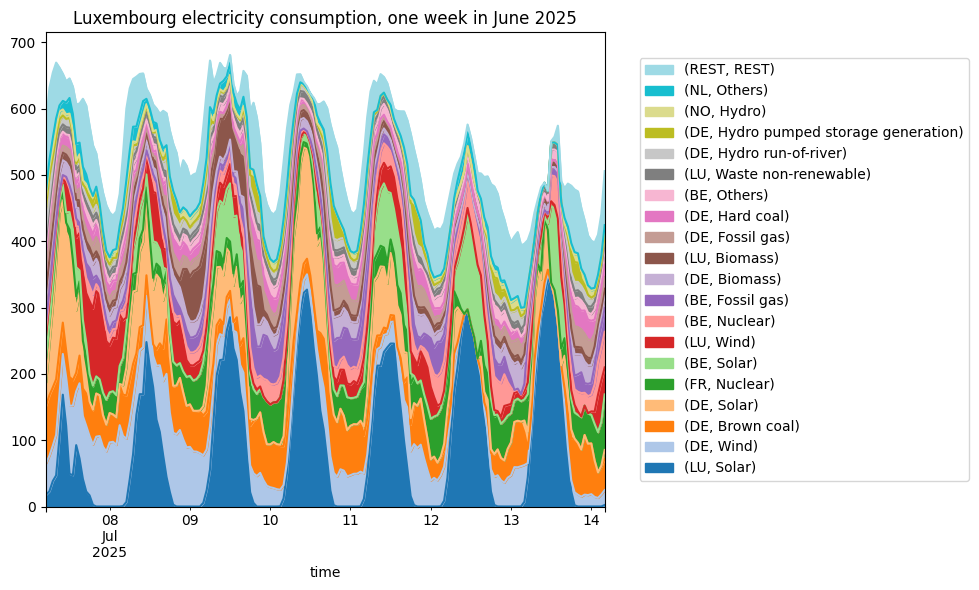

In [31]:
title = "Luxembourg electricity consumption, one week in June 2025"
Z_to_plot = apply_top_n_cutoff(
    Z=Z_cons_2025_LU.iloc[:, max_solar : max_solar + 24 * 7],
    top_n=19,
    rest_label=("REST", "REST"),
    # ).droplevel("source", axis=0)
).droplevel("source", axis=1)

ax = Z_to_plot.clip(0).T.plot.area(stacked=True, figsize=(10, 6), colormap="tab20")
h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1], bbox_to_anchor=(1.05, 0.5), loc="center left")
ax.set_title(title)

plt.tight_layout()

plt.savefig(f"../figures/{title}.png", dpi=300)

In [10]:
# Country aggregation

Text(0.5, 1.0, 'Luxembourg electricity consumption, by country, February 2025')

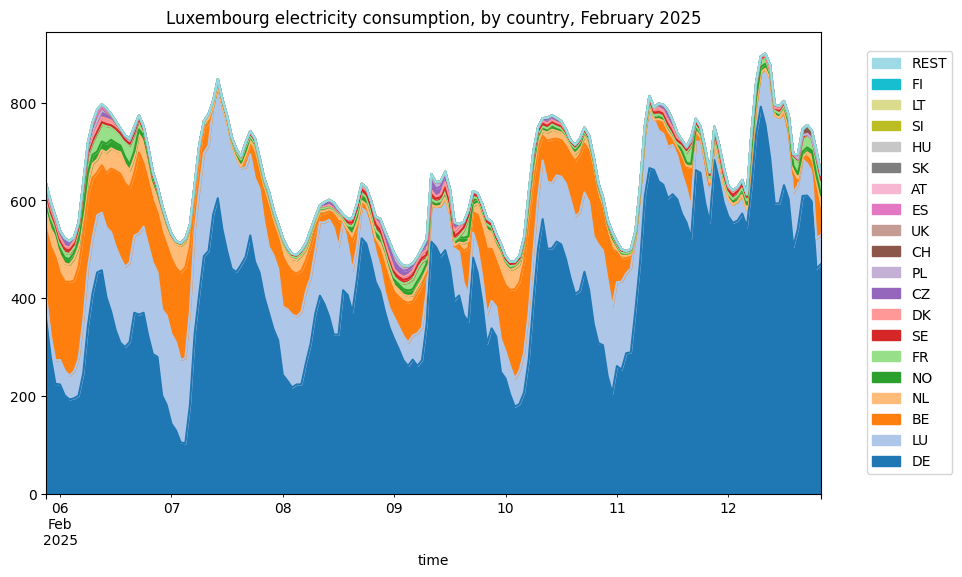

In [11]:
Z_to_plot = apply_top_n_cutoff(
    Z=Z_cons_2025_LU_reg.iloc[:, max_lignite : max_lignite + 24 * 7],
    top_n=19,
).droplevel("source", axis=1)

ax = Z_to_plot.clip(0).T.plot.area(stacked=True, figsize=(10, 6), colormap="tab20")
h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1], bbox_to_anchor=(1.05, 0.5), loc="center left")
ax.set_title("Luxembourg electricity consumption, by country, February 2025")

Text(0.5, 1.0, 'Luxembourg electricity consumption, by country, June 2025')

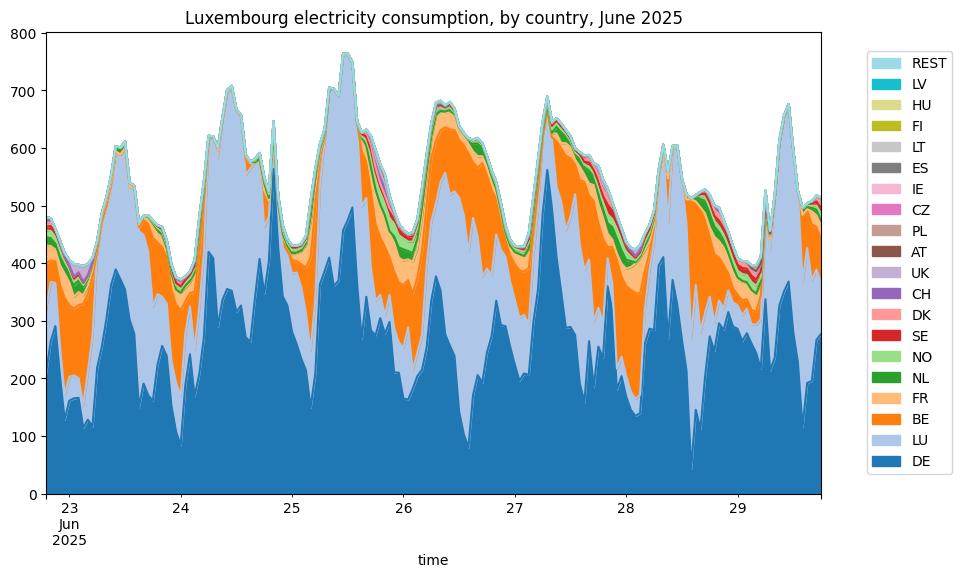

In [12]:
Z_to_plot = apply_top_n_cutoff(
    Z=Z_cons_2025_LU_reg.iloc[:, max_solar : max_solar + 24 * 7],
    top_n=19,
).droplevel("source", axis=1)

ax = Z_to_plot.clip(0).T.plot.area(stacked=True, figsize=(10, 6), colormap="tab20")
h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1], bbox_to_anchor=(1.05, 0.5), loc="center left")
ax.set_title("Luxembourg electricity consumption, by country, June 2025")

In [13]:
# Technology aggregation

Text(0.5, 1.0, 'Luxembourg electricity consumption, by technology, February 2025')

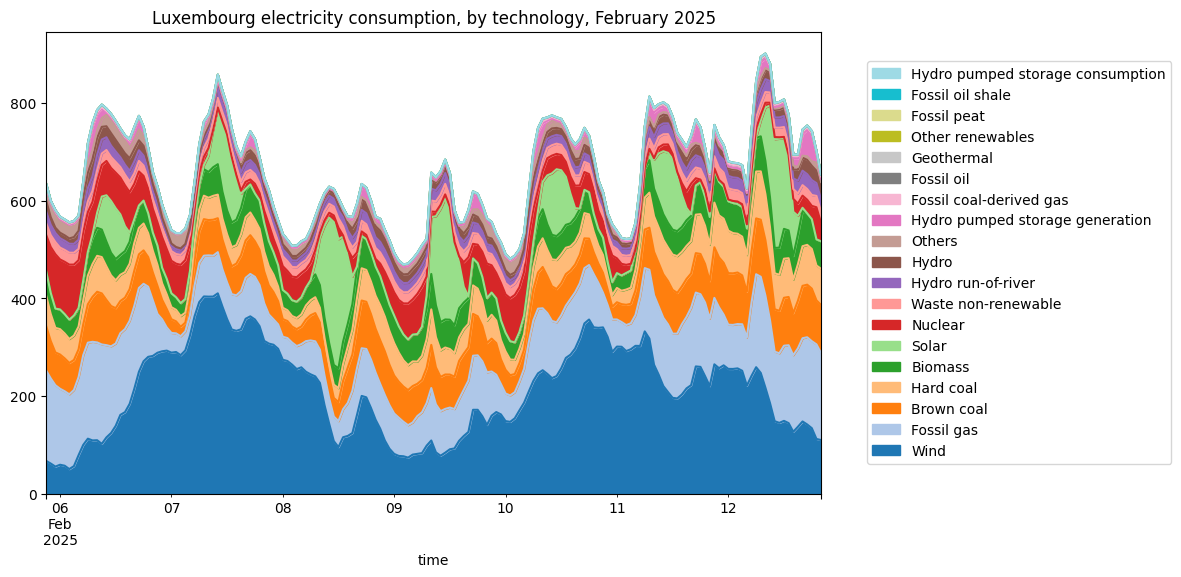

In [14]:
Z_to_plot = apply_top_n_cutoff(
    Z=Z_cons_2025_LU_tech.iloc[:, max_lignite : max_lignite + 24 * 7],
    top_n=19,
).droplevel("source", axis=1)

ax = Z_to_plot.clip(0).T.plot.area(stacked=True, figsize=(10, 6), colormap="tab20")
h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1], bbox_to_anchor=(1.05, 0.5), loc="center left")
ax.set_title("Luxembourg electricity consumption, by technology, February 2025")

Text(0.5, 1.0, 'Luxembourg electricity consumption, by technology, June 2025')

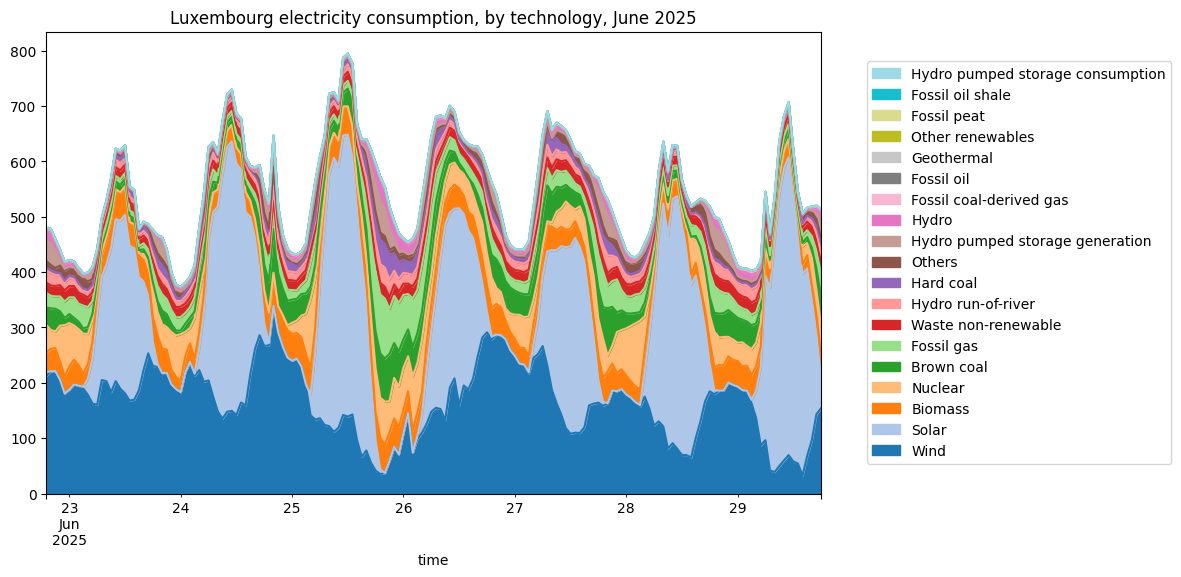

In [15]:
Z_to_plot = apply_top_n_cutoff(
    Z=Z_cons_2025_LU_tech.iloc[:, max_solar : max_solar + 24 * 7],
    top_n=19,
).droplevel("source", axis=1)

ax = Z_to_plot.clip(0).T.plot.area(stacked=True, figsize=(10, 6), colormap="tab20")

h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1], bbox_to_anchor=(1.05, 0.5), loc="center left")
ax.set_title("Luxembourg electricity consumption, by technology, June 2025")

In [16]:
# Prospective data

In [17]:
scenario = "GA"  # DE = Distributed Energy, GA = Global Ambition, NT = National Trends
year = 2040  # DE/GA: 2035, 2040, 2050; NT: 2030, 2040
climate_year = 2009  # 1995, 2008, 2009

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_dir = repo_root / "data" / "tyndp" / "cache"
tyndp_mapping_dir = files("shrecc") / "data" / "tyndp"
technology_mapping = tyndp_mapping_dir / "tyndp_activities.csv"
country_mapping = tyndp_mapping_dir
ecoinvent_mapping = files("shrecc") / "data" / "el_map_all_norm.csv"

In [18]:
Z_cons_2040 = consumption_mix_from_tyndp_scenario(
    scenario=scenario,  # User input
    year=year,  # User input
    climate_year=climate_year,  # User input
    data_dir=data_dir,  # This should be ultimately hidden
    technology_mapping=technology_mapping,  # This should be ultimately hidden
    country_mapping=country_mapping,  # This should be ultimately hidden
    zero_consumption="month_hour_average",  # This should be ultimately hidden
    check=True,  # This should be True by default
    verbose=True,  # This should be True by default
)

2026-07-15 14:33:37 Loading TYNDP pickle files
2026-07-15 14:33:38 Parsing hourly datetime index
2026-07-15 14:33:39 Loading technology and country mappings
2026-07-15 14:33:39 Aggregating hourly production by country and technology


D:\shrecc_project\shrecc\shrecc\tyndp.py:1151: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  production = production.groupby(


2026-07-15 14:33:39 Aggregating hourly trade to positive directional country flows


D:\shrecc_project\shrecc\shrecc\tyndp.py:292: UserWarning: Dropping trade columns without country-pair mappings: AT00-AT00EV, AT00-AT00RETE, AT00EV-AT00, AT00EV-AT00RETE, AT00RETE-AT00EV, BE00-BE00EV, BE00-BE00RETE, BE00EV-BE00, BE00EV-BE00RETE, BE00RETE-BE00EV
  trade_directional = _aggregate_tyndp_trade(trade, connections)
D:\shrecc_project\shrecc\shrecc\tyndp.py:1213: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  trade = trade.groupby(level=["Country from", "Country to"], axis=1).sum()


2026-07-15 14:33:40 Combining production and trade into Z_gross
2026-07-15 14:33:40 Built Z_gross with shape (8736, 511)
2026-07-15 14:33:40 Building domestic production and trade denominator matrices


D:\shrecc_project\shrecc\shrecc\tyndp.py:1317: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(["country from", "country to"], axis=1)
D:\shrecc_project\shrecc\shrecc\tyndp.py:1337: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  country_total = Z_trade.groupby("country to", axis=1).sum()


2026-07-15 14:33:40 Calculating direct production and trade shares
2026-07-15 14:33:40 Using 35 countries and 31 technologies
2026-07-15 14:33:40 Reshaping production shares
2026-07-15 14:33:43 Reshaping trade shares
2026-07-15 14:33:44 Checking direct shares sum to one
2026-07-15 14:33:44 Solving hourly trade system
2026-07-15 14:34:06 Imputing zero-consumption country-hours with month-hour averages
2026-07-15 14:34:06 Checking final consumption mix sums to one
2026-07-15 14:34:06 Building xarray DataArray
2026-07-15 14:34:24 Built consumption_mix_xr with shape (8736, 35, 35, 31)


In [19]:
Z_cons_2040_LU = (
    Z_cons_2040.sel(consumer_country="LU")
    .to_dataframe()["consumption_mix"]
    .unstack(["source_country", "technology"])
)

In [20]:
index_order = Z_cons_2040_LU.sum().sort_values(ascending=False).index
Z_cons_2040_LU = Z_cons_2040_LU.reindex(columns=index_order).T

In [21]:
index_order_reg = index_order.get_level_values("source_country").unique()
index_order_tech = index_order.get_level_values("technology").unique()


# ...by country
Z_cons_2040_LU_reg = (
    Z_cons_2040_LU.groupby("source_country", axis=0)
    .sum()
    .reindex(index=index_order_reg)
)

# ...by technology
Z_cons_2040_LU_tech = (
    Z_cons_2040_LU.groupby("technology", axis=0).sum().reindex(index=index_order_tech)
)

C:\Users\Gibon\AppData\Local\Temp\ipykernel_30612\4054710375.py:7: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  Z_cons_2040_LU.groupby("source_country", axis=0)
C:\Users\Gibon\AppData\Local\Temp\ipykernel_30612\4054710375.py:14: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  Z_cons_2040_LU.groupby("technology", axis=0).sum().reindex(index=index_order_tech)


In [22]:
max_nuclear = (
    Z_cons_2040_LU_tech.rolling(window=24 * 7, min_periods=1, axis=1)
    .sum()
    .loc["Nuclear [MW]"]
    .argmax()
)
max_solar = (
    Z_cons_2040_LU_tech.rolling(window=24 * 7, min_periods=1, axis=1)
    .sum()
    .loc["Solar (Photovoltaic) [MW]"]
    .argmax()
)

C:\Users\Gibon\AppData\Local\Temp\ipykernel_30612\2421052699.py:2: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  Z_cons_2040_LU_tech.rolling(window=24 * 7, min_periods=1, axis=1)
C:\Users\Gibon\AppData\Local\Temp\ipykernel_30612\2421052699.py:8: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  Z_cons_2040_LU_tech.rolling(window=24 * 7, min_periods=1, axis=1)


In [23]:
# All disaggregation

In [24]:
Z_to_plot = apply_top_n_cutoff(
    Z=Z_cons_2040_LU.iloc[:, max_nuclear : max_nuclear + 24 * 7],
    top_n=19,
    rest_label=("REST", "REST"),
    # ).droplevel("source", axis=0)
)

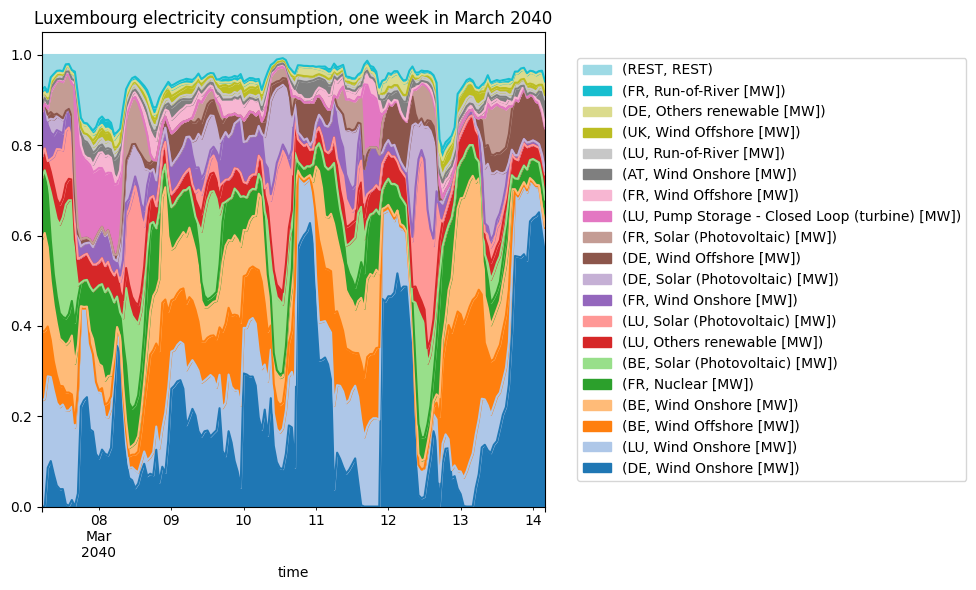

In [35]:
title = "Luxembourg electricity consumption, one week in March 2040"

Z_to_plot = apply_top_n_cutoff(
    Z=Z_cons_2040_LU.iloc[:, max_nuclear : max_nuclear + 24 * 7],
    top_n=19,
    rest_label=("REST", "REST"),
    # ).droplevel("source", axis=0)
)


ax = Z_to_plot.clip(0).T.plot.area(stacked=True, figsize=(10, 6), colormap="tab20")
h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1], bbox_to_anchor=(1.05, 0.5), loc="center left")
ax.set_title(title)

plt.tight_layout()
plt.savefig(f"../figures/{title}.png", dpi=300)

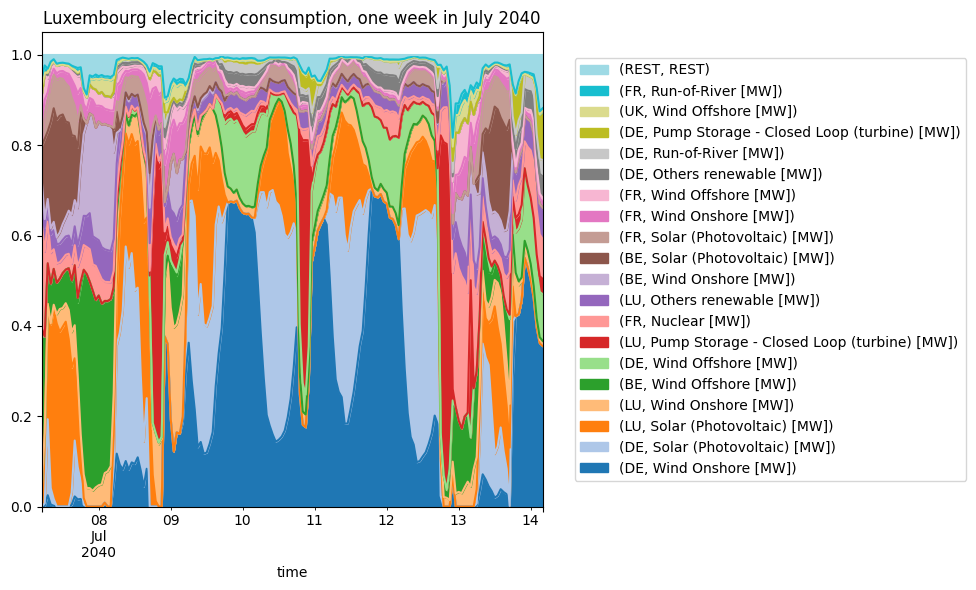

In [36]:
title = "Luxembourg electricity consumption, one week in July 2040"

Z_to_plot = apply_top_n_cutoff(
    Z=Z_cons_2040_LU.iloc[:, max_solar : max_solar + 24 * 7],
    top_n=19,
    rest_label=("REST", "REST"),
    # ).droplevel("source", axis=0)
)


ax = Z_to_plot.clip(0).T.plot.area(stacked=True, figsize=(10, 6), colormap="tab20")
h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1], bbox_to_anchor=(1.05, 0.5), loc="center left")
ax.set_title(title)

plt.tight_layout()
plt.savefig(f"../figures/{title}.png", dpi=300)